# Sanity check — soft-vs-hard data pipeline

Two checks before we trust the data:

1. **Eyeball plot** of all 17 series with NBER recession bands. If this looks like every macro chart you've ever seen (UR spiking 2008/2020, VIX peaking Sep 2008 and Mar 2020, sentiment crashing 2008/2022), the pipeline is fundamentally sound.
2. **Vintage spot-checks** on the cubes: no future leakage, magnitudes match known historical releases, and the rebasing fix actually works.

Run top to bottom.

In [1]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # so we can import sibling modules

import pandas as pd
import matplotlib.pyplot as plt
import yaml
from fredapi import Fred

import vintage_store

ROOT = Path.cwd().parent
csv_files = sorted((ROOT / 'data' / 'vintages').glob('*.csv'))
df = pd.read_csv(csv_files[-1], parse_dates=['date']).set_index('date')
print(f'Loaded {csv_files[-1].name}  shape={df.shape}  range={df.index.min().date()}..{df.index.max().date()}')

cfg = yaml.safe_load(open(ROOT / 'config.yaml'))
fred = Fred(api_key=cfg['api_key'])
nber = fred.get_series('USRECM').reindex(df.index)
print(f'NBER recession indicator loaded ({int((nber == 1).sum())} recession months in window)')

Loaded 2026-05-23_18-16-35.csv  shape=(437, 17)  range=1990-01-01..2026-05-01


NBER recession indicator loaded (40 recession months in window)


## 1. Eyeball plot

All 17 series in a grid. NBER recession windows shaded grey. Colour-coded by group: blue=hard, green=soft_long, purple=soft_short, red=regime.

Quarterly series (gdp_real, sloos_ci_tightening) get markers so they're visible against the monthly grid.

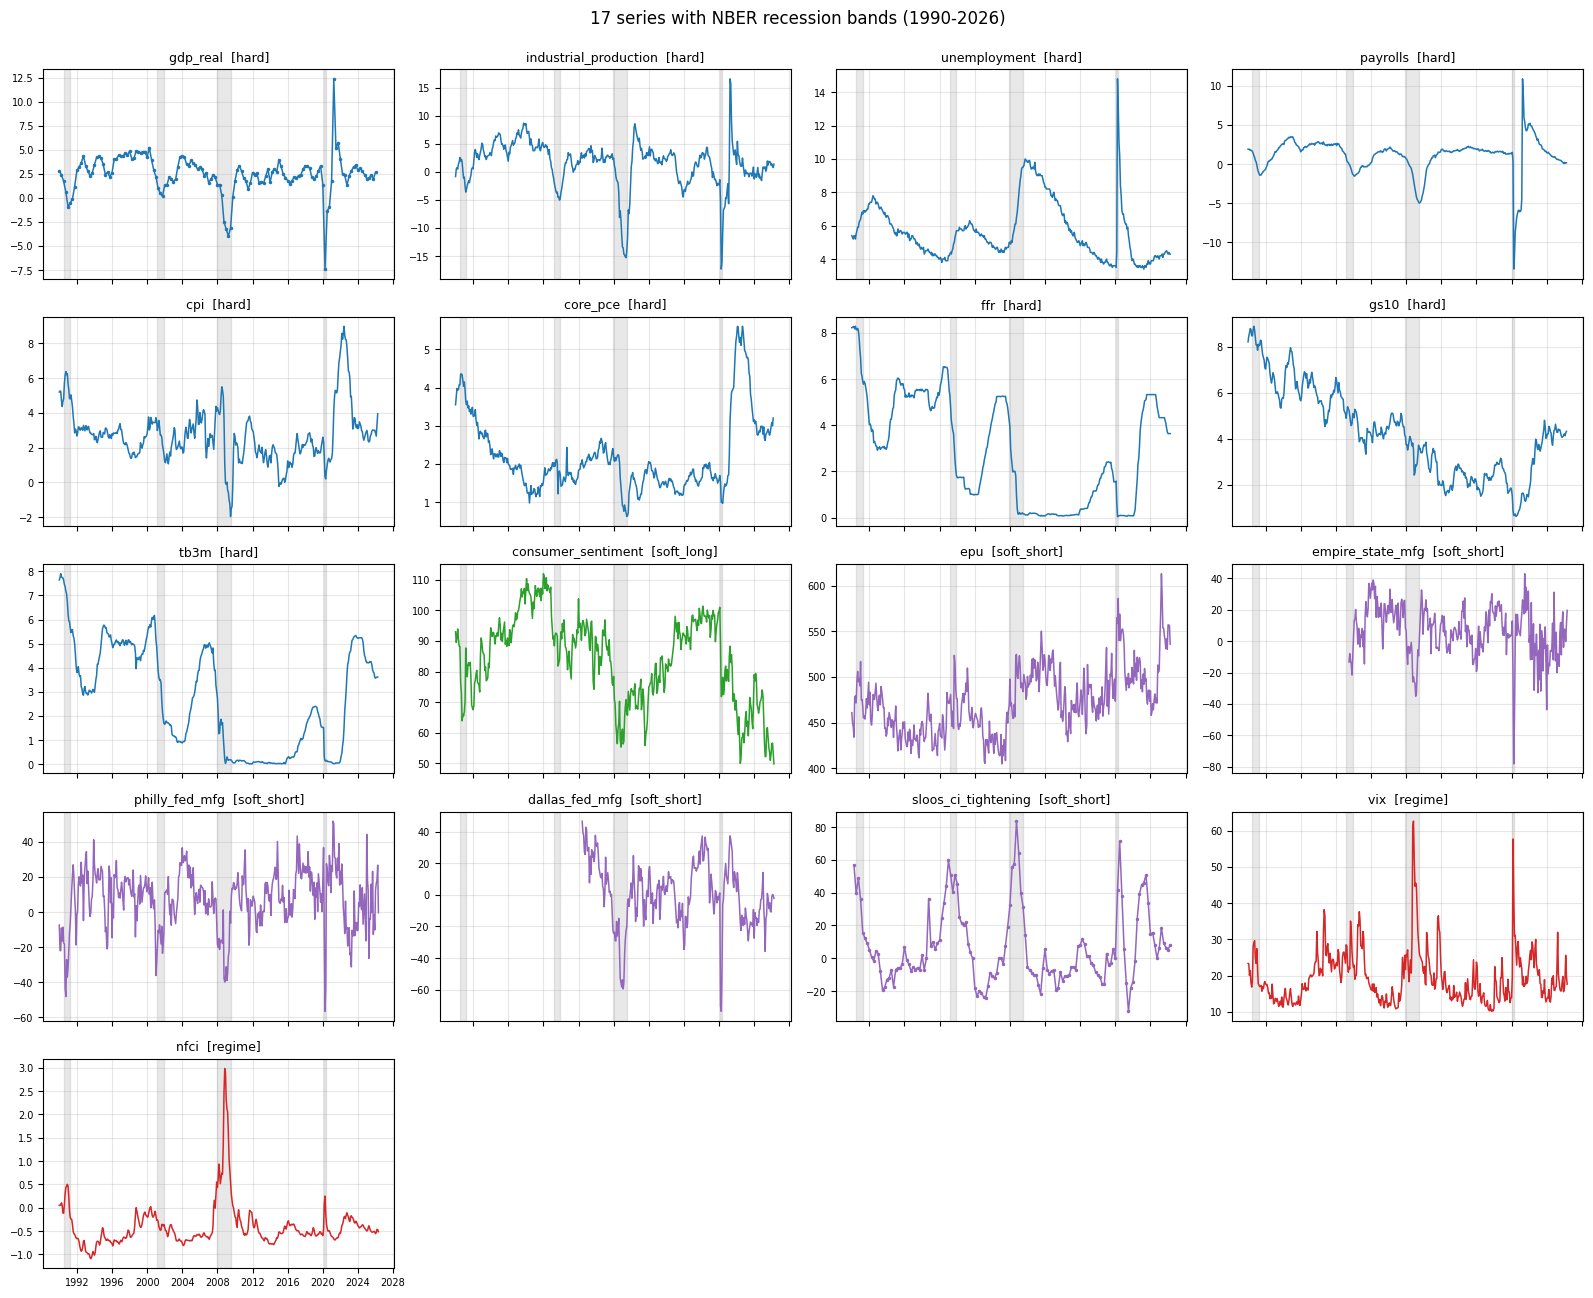

In [2]:
def recession_bands(nber_series):
    s = nber_series.fillna(0).astype(int)
    out, in_rec, start = [], False, None
    for d, v in s.items():
        if v == 1 and not in_rec:
            start, in_rec = d, True
        elif v == 0 and in_rec:
            out.append((start, d)); in_rec = False
    if in_rec: out.append((start, s.index[-1]))
    return out

bands = recession_bands(nber)

groups = {
    'hard':       ['gdp_real', 'industrial_production', 'unemployment', 'payrolls',
                   'cpi', 'core_pce', 'ffr', 'gs10', 'tb3m'],
    'soft_long':  ['consumer_sentiment'],
    'soft_short': ['epu', 'empire_state_mfg', 'philly_fed_mfg', 'dallas_fed_mfg',
                   'sloos_ci_tightening'],
    'regime':     ['vix', 'nfci'],
}
ordered = [c for g in groups.values() for c in g if c in df.columns]
which   = {c: g for g, cs in groups.items() for c in cs}
colors  = {'hard': '#1f77b4', 'soft_long': '#2ca02c',
           'soft_short': '#9467bd', 'regime': '#d62728'}

n = len(ordered); ncols = 4; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 2.6 * nrows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(ordered):
    ax = axes[i]
    s = df[col].dropna()
    sparse = len(s) < len(df) * 0.5
    ax.plot(s.index, s.values, color=colors[which[col]], lw=1.1,
            marker='.' if sparse else None, markersize=3)
    ax.set_title(f'{col}  [{which[col]}]', fontsize=9)
    ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
    for s_, e_ in bands:
        ax.axvspan(s_, e_, color='grey', alpha=0.18)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('17 series with NBER recession bands (1990-2026)', y=0.995, fontsize=12)
plt.tight_layout()
plt.show()

**What to look for**

- `unemployment` spikes at every recession; massive 2020 spike (~15%).
- `industrial_production` and `payrolls` plunge in 2008-9 and 2020.
- `cpi` spikes to 9% in 2022.
- `ffr` shows zero-bound era 2008-2015 and the 2022 hiking cycle.
- `consumer_sentiment` hits its all-time low (50) in June 2022.
- `vix` peaks above 60 in Sep-Oct 2008 and March 2020.
- `nfci` spikes above 2 in 2008.
- `epu` spikes around 2008, 2011 debt ceiling, 2020 COVID.

If any of those visual landmarks are missing or flipped, there's a bug.

## 2. Vintage cube spot-checks

Three things to verify on the cubes:

### A. No future leakage

`snapshot_as_of(date)` must not return any observation released after `date`. Otherwise the forecast harness is cheating.

In [3]:
gdp_cube = vintage_store.load_cube(ROOT / 'data/vintages/cubes/GDPC1.parquet')
ur_cube  = vintage_store.load_cube(ROOT / 'data/vintages/cubes/UNRATE.parquet')

for cube_name, cube, as_of in [
    ('GDPC1',  gdp_cube, '2008-01-01'),
    ('UNRATE', ur_cube,  '2020-04-15'),
]:
    snap = vintage_store.snapshot_as_of(cube, as_of)
    last = snap.dropna().index.max()
    leak = last >= pd.Timestamp(as_of)
    flag = 'FAIL — future leakage!' if leak else 'pass'
    print(f'{cube_name} snapshot as of {as_of}: last non-NaN obs = {last.date()}   [{flag}]')

GDPC1 snapshot as of 2008-01-01: last non-NaN obs = 2007-07-01   [pass]
UNRATE snapshot as of 2020-04-15: last non-NaN obs = 2020-03-01   [pass]


### B. Magnitudes match historical releases

Three landmark events whose values are public knowledge:

In [4]:
# April 2020 unemployment: BLS first reported 14.7% on May 8, 2020
snap = vintage_store.snapshot_as_of(ur_cube, '2020-06-01')
apr_ur = float(snap.loc['2020-04-01'])
print(f'UNRATE Apr 2020, snapshot 2020-06-01:  {apr_ur:.1f}   (BLS first reported 14.7 on May 8 2020)')

# 2008-Q4 GDP first release was Jan 30 2009. YoY vs 2007-Q4 should be slightly negative.
snap = vintage_store.snapshot_as_of(gdp_cube, '2009-02-15')
q4_08 = float(snap.loc['2008-10-01'])
q4_07 = float(snap.loc['2007-10-01'])
yoy = 100 * (q4_08 - q4_07) / q4_07
print(f'GDP Q4 2008 level, snapshot 2009-02-15: {q4_08:.1f}')
print(f'GDP Q4 2008 YoY (first-release basis):  {yoy:+.2f}%')

# UMCSENT June 2022 all-time low
ums = df['consumer_sentiment']
print(f'UMCSENT Jun 2022 (in flat snapshot):    {float(ums.loc["2022-06-01"]):.1f}   (all-time low was 50.0)')

# VIX peaks
vix = df['vix']
print(f'VIX monthly mean peak Sep-Dec 2008:     {vix.loc["2008-09-01":"2008-12-01"].max():.1f}')
print(f'VIX monthly mean peak Feb-Apr 2020:     {vix.loc["2020-02-01":"2020-04-01"].max():.1f}')

UNRATE Apr 2020, snapshot 2020-06-01:  14.7   (BLS first reported 14.7 on May 8 2020)
GDP Q4 2008 level, snapshot 2009-02-15: 11599.4
GDP Q4 2008 YoY (first-release basis):  -0.18%
UMCSENT Jun 2022 (in flat snapshot):    50.0   (all-time low was 50.0)
VIX monthly mean peak Sep-Dec 2008:     62.7
VIX monthly mean peak Feb-Apr 2020:     57.7


### C. The rebasing fix actually works

Real GDP gets rebased every ~5 years (latest annual update: 25 July 2024 — chained 2012 dollars → chained 2017 dollars). Computing YoY across a rebasing using mixed-base first-release levels would give a spurious ~10% spike.

The cube approach uses *vintage-consistent* snapshots: every observation in one snapshot reflects the same base year. So YoY values should be stable across vintage dates that straddle the rebasing.

In [5]:
print('GDP YoY (last 4 quarters), as known on each vintage date:')
print()
rows = []
for vd in ['2024-07-01', '2024-08-01', '2024-09-30']:
    snap = vintage_store.snapshot_as_of(gdp_cube, vd)
    snap_n = pd.to_numeric(snap, errors='coerce').dropna()
    yoy = (100 * (snap_n - snap_n.shift(4)) / snap_n.shift(4)).dropna()
    rows.append(pd.Series(yoy.tail(4).values, index=yoy.tail(4).index, name=vd))

out = pd.concat(rows, axis=1)
out.columns = [f'as of {c}' for c in out.columns]
print(out.round(3).to_string())
print()
print('The first row (2024-Q1 in 2024-07-01 vs 2024-08-01) should be IDENTICAL')
print('(those vintages straddle the July 25 2024 rebasing but their snapshots are each internally consistent).')
print()
print('Compare to first-release LEVELS (which mix base years):')
fr = vintage_store.first_release_series(gdp_cube)
fr_n = pd.to_numeric(fr, errors='coerce').dropna()
fr_yoy = (100 * (fr_n - fr_n.shift(4)) / fr_n.shift(4)).dropna()
print(fr_yoy.loc['2023-10-01':'2024-10-01'].round(3))
print('(would show a spurious ~12% spike at 2024-Q2 because of base-year change)')

GDP YoY (last 4 quarters), as known on each vintage date:

            as of 2024-07-01  as of 2024-08-01  as of 2024-09-30
date                                                            
2023-04-01             2.382               NaN               NaN
2023-07-01             2.927             2.927             3.236
2023-10-01             3.134             3.134             3.196
2024-01-01             2.923             2.923             2.902
2024-04-01               NaN             3.120             3.037

The first row (2024-Q1 in 2024-07-01 vs 2024-08-01) should be IDENTICAL
(those vintages straddle the July 25 2024 rebasing but their snapshots are each internally consistent).

Compare to first-release LEVELS (which mix base years):
2023-10-01    12.252
2024-01-01    12.517
2024-04-01    12.324
2024-07-01     3.978
2024-10-01     3.784
dtype: float64
(would show a spurious ~12% spike at 2024-Q2 because of base-year change)


## Summary

If everything above is sensible:

- Pipeline data is correctly aligned and scaled.
- Vintage cubes return as-of snapshots without future leakage.
- Magnitudes match documented historical releases.
- The rebasing fix works — YoY is computed within each vintage's base year, not across base-year changes.

Ready for M2: pseudo-real-time forecast harness.